# **IMPORT LIBRARY**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = '/content/supermarket_salesnew.csv'

df = pd.read_csv(file)
df

,Gender,Branch,City,Customer type,Product line,Unit price,Quantity,Tax 5%,Total Before Tax,Total Sales
0,Female,A,Yangon,Member,Health and beauty,74.69,7,58.731875,522.83,581.561875
1,Female,C,Naypyitaw,Normal,Electronic accessories,15.28,5,3.820000,76.40,80.220000
2,Female,A,Yangon,Member,Electronic accessories,68.84,6,20.652000,413.04,433.692000
3,Female,C,Naypyitaw,Normal,Home and lifestyle,73.56,10,36.780000,735.60,772.380000
4,Female,A,Yangon,Member,Health and beauty,36.26,2,3.626000,72.52,76.146000
...,...,...,...,...,...,...,...,...,...,...
995,Male,A,Yangon,Normal,Electronic accessories,58.03,2,5.803000,116.06,121.863000
996,Male,B,Mandalay,Normal,Fashion accessories,17.49,10,8.745000,174.90,183.645000
997,Male,C,Naypyitaw,Normal,Health and beauty,40.35,1,2.017500,40.35,42.367500
998,Male,A,Yangon,Member,Food and beverages,31.84,1,1.592000,31.84,33.432000


# **VISUALISASI DATA**

# **Bar Chart**

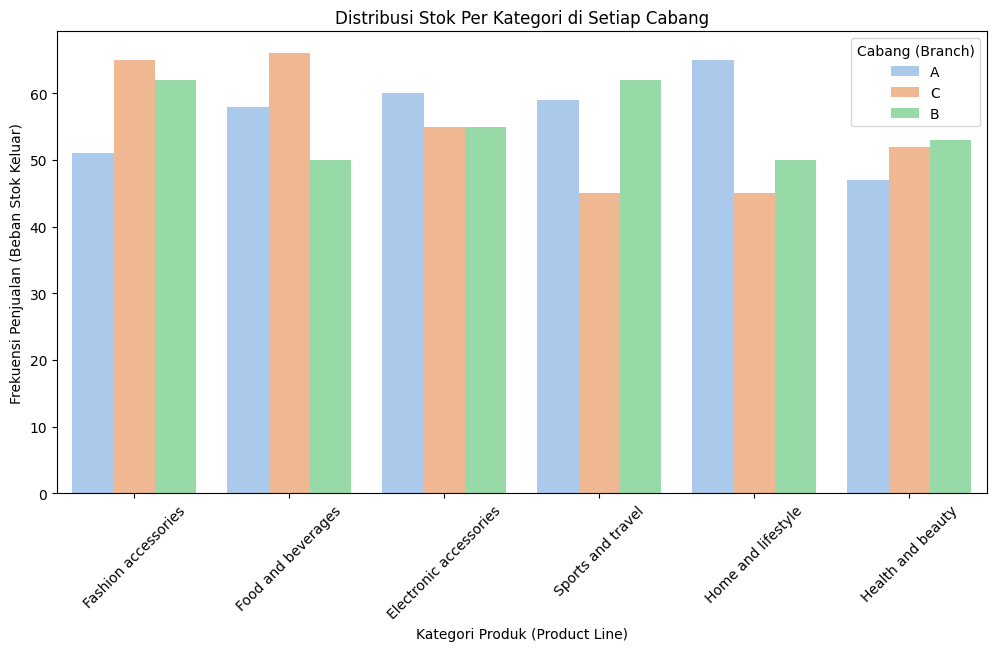

In [6]:
VARIABEL1 = df['Product line'].value_counts().head(6).sort_values(ascending=False)
VARIABEL2 = df[df['Product line'].isin(VARIABEL1.index)]

plt.figure(figsize=(12, 6))

sns.countplot(x='Product line', data=VARIABEL2, hue="Branch", palette='pastel', order=VARIABEL1.index)

plt.title('Distribusi Stok Per Kategori di Setiap Cabang')
plt.xlabel('Product Line')
plt.ylabel('Frekuensi Penjualan (Beban Stok Keluar)')
plt.xticks(rotation=45)
plt.legend(title='Cabang (Branch)')
plt.show()


Dapat terlihat grafik chart dari distribusi stok per kategori ditiap cabang serta frekuensi penjualannya.

**Insight yang didapat:**

* Ada nya ketimpangan stok, dimana Kategori Home and Lifestyle sangat laku di Cabang A, tapi menjadi beban di Cabang C.
* Cabang C adalah penguasa pasar Food and Beverages dan Fashion, namun kategori lainnya cenderung rendah.
* Produk Electronic Accessories memiliki distribusi penjualan yang paling merata di semua cabang (A, B, dan C).

**action:**
* Di Cabang C, fokuskan ruang gudang hanya untuk Food dan Fashion. Jangan menumpuk barang olahraga (Sports) karena peminatnya rendah di sana.
* Karena Electronic Accessories stabil di mana-mana, jadikan produk ini sebagai stok prioritas. Beli dalam jumlah besar dari supplier untuk mendapatkan harga modal lebih murah.

# **Pie Chart**

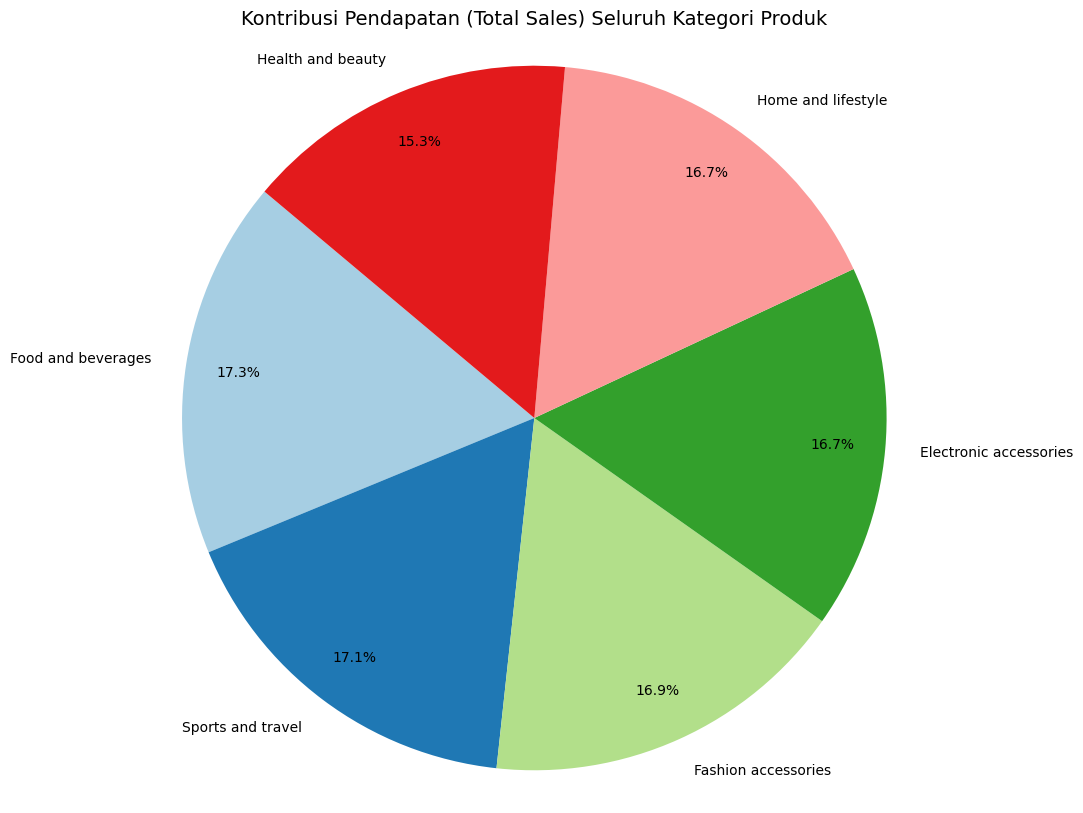

In [13]:
VARIABEL1 = df.groupby('Product line')['Total Sales'].sum().sort_values(ascending=False)
VARIABEL2 = VARIABEL1

plt.figure(figsize=(10, 10))

VARIABEL2.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors,pctdistance=0.85)


plt.title('Kontribusi Pendapatan (Total Sales) Seluruh Kategori Produk', fontsize=14)
plt.ylabel('')
plt.axis('equal')
plt.show()


Dapat terlihat grafik Pie chart dari kontribusi pendapatan seluruh kategori produk.

**Insight yang didapat:**

* Food and Beverages (17.3%) dan Sports and Travel (17.1%) adalah penyumbang uang tunai terbesar bagi perusahaan.
* Health and Beauty memiliki kontribusi terendah (15.3%)

**action:**
* Kurangi jumlah stok atau luas area pajangan untuk kategori Health and Beauty ini.
* Karena Food & Beverages adalah penyumbang uang terbesar, maka lakukan negosiasi ulang dengan supplier untuk mendapatkan harga modal lebih murah guna mempertebal Untung Besar.

# **Line Chart**

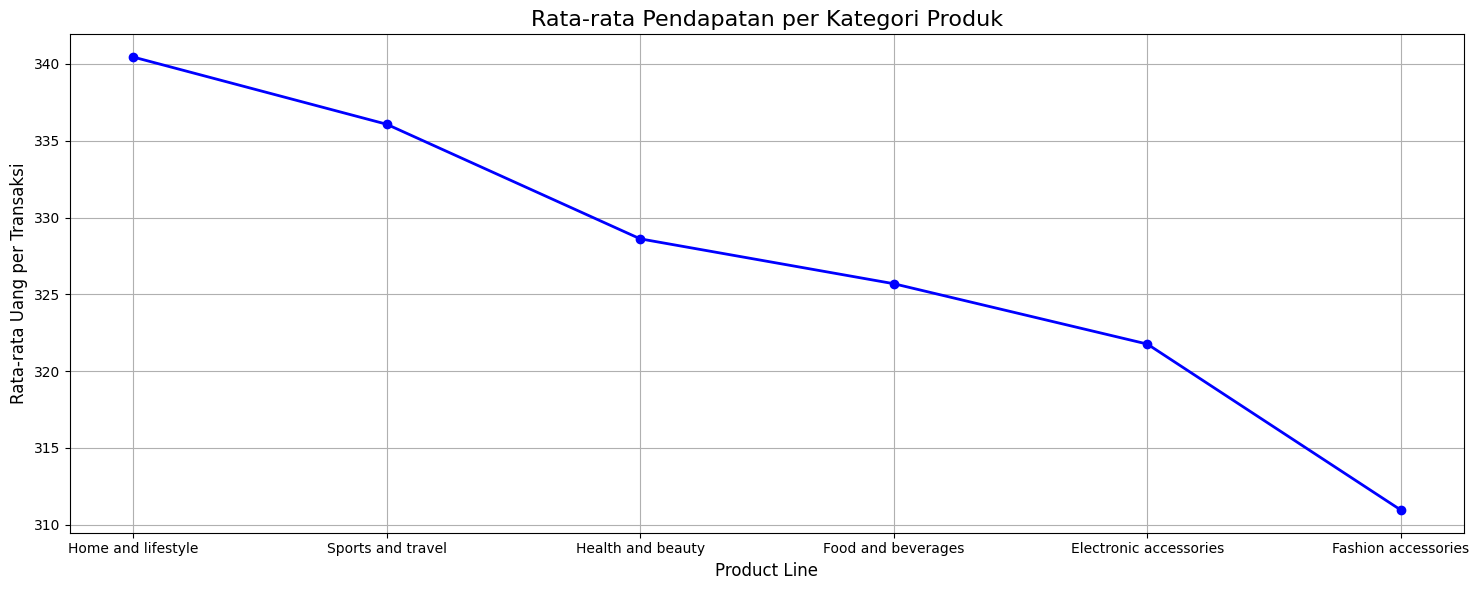

In [19]:
VARIABEL1 = df.groupby('Product line')['Total Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
plt.plot(VARIABEL1.index.astype(str), VARIABEL1.values, marker='o', color='blue', linewidth=2)
plt.title('Rata-rata Pendapatan per Kategori Produk', fontsize=16)
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Rata-rata Uang per Transaksi', fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()


Berdasarkan grafik Line Chart Rata-rata Pendapatan per Kategori Produk,

**Insight yang didapat:**
* Home and lifestyle dan Sports and travel berada di titik tertinggi (rata-rata >335 per transaksi). Ini adalah produk "Efisien" karena setiap transaksi menghasilkan uang yang besar
* Fashion accessories berada di titik terendah (rata-rata ~311 per transaksi). Kategori ini di grafik bar chart sebelumnya terjual sangat banyak (laku), maka ini adalah konfirmasi bahwa produk ini adalah Beban Stok (Sangat sibuk operasionalnya, tapi uang per transaksinya kecil).

**action:**
* Memprioritaskan ketersediaan stok pada kategori Home and Lifestyle karena efektivitasnya dalam menghasilkan uang per transaksi sangat tinggi.
* Meningkatkan nilai transaksi Fashion Accessories melalui paket bundling (misal: "Beli 3 Lebih Hemat") untuk menaikkan rata-rata nilai penjualan dan mempercepat perputaran stok yang mengendap.

# **Histogram**

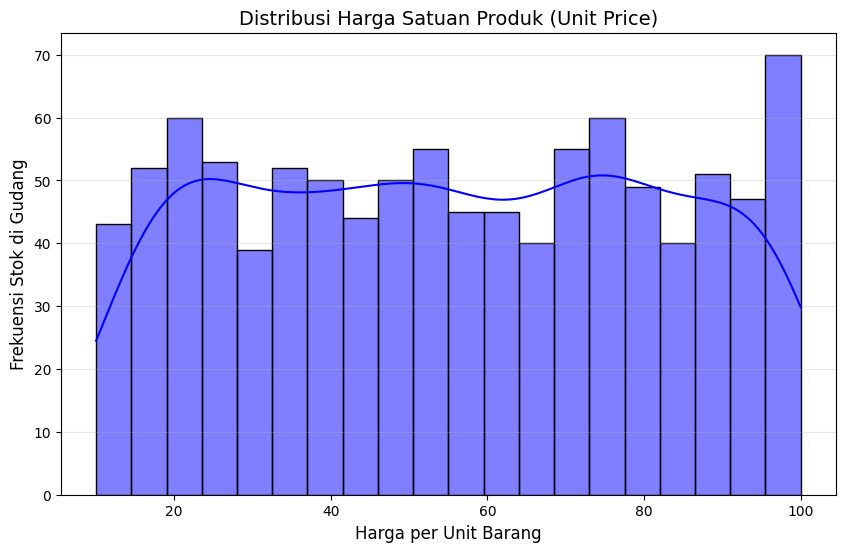

In [22]:

plt.figure(figsize=(10, 6))

# Menggunakan 'Unit price' untuk melihat distribusi harga stok barang
sns.histplot(df['Unit price'], bins=20, kde=True, color='blue')

plt.title('Distribusi Harga Satuan Produk (Unit Price)', fontsize=14)
plt.xlabel('Harga per Unit Barang', fontsize=12)
plt.ylabel('Frekuensi Stok di Gudang', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


Berdasarkan grafik Histogram Distribusi unit price,

**Insight yang didapat:**
* Stok barang tersebar cukup merata di semua rentang harga, dari yang murah (10) hingga mahal (100).
* Terdapat lonjakan frekuensi tertinggi pada rentang harga 95 - 100. Artinya, gudang saat ini menyimpan sangat banyak produk mahal yang berpotensi menghasilkan Untung Besar dalam satu kali transaksi.

**action:**
* Untuk produk di rentang harga 20-30 yang frekuensinya tinggi, maka harus dipastikan penjualannya cepat. Jika melambat, kategori ini akan menjadi Beban Stok.

# **Box Plot**

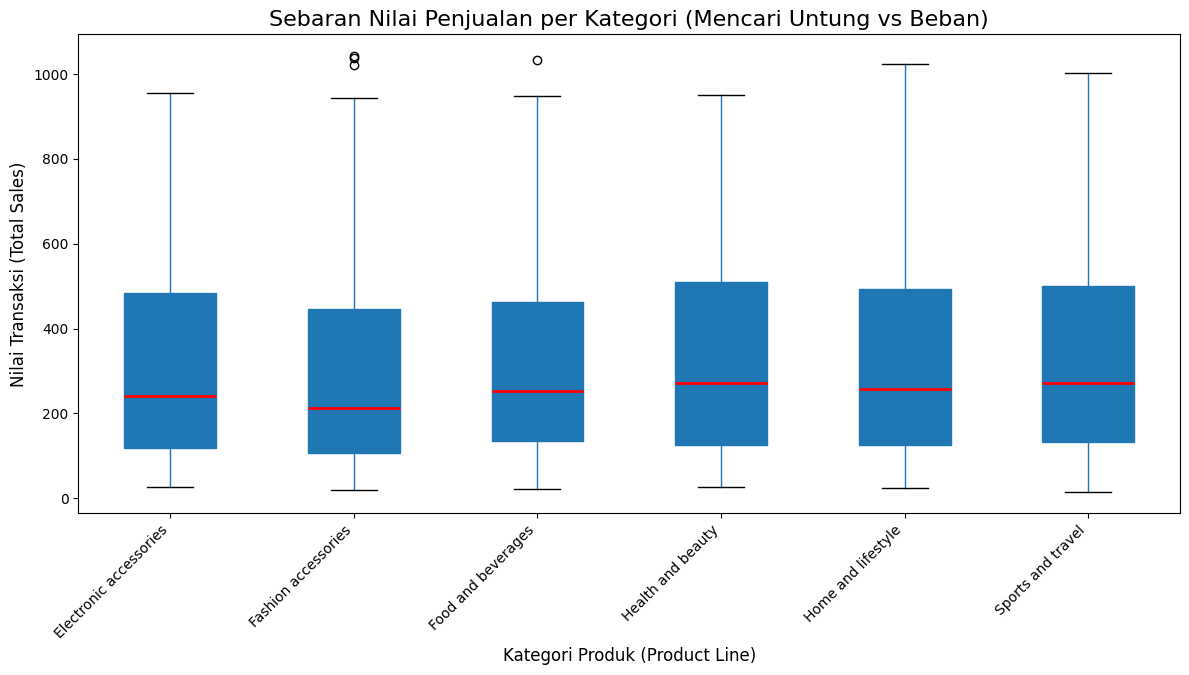

In [25]:
VARIABEL1 = df['Product line'].value_counts().head(6).index
VARIABEL2 = df[df['Product line'].isin(VARIABEL1)]

plt.figure(figsize=(12, 7))
VARIABEL2.boxplot(column='Total Sales', by='Product line', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red', linewidth=2))

plt.title('Sebaran Nilai Penjualan per Kategori (Mencari Untung vs Beban)', fontsize=16)
plt.xlabel('Kategori Produk (Product Line)', fontsize=12)
plt.ylabel('Nilai Transaksi (Total Sales)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.suptitle('')
plt.tight_layout()
plt.show()


Berdasarkan grafik Box Plot sebaran nilai penjualan perkategori di atas, maka

**Insight yang didapat:**
* Kategori Health and beauty dan Sports and travel memiliki garis merah (median) tertinggi. Artinya, secara rata-rata, satu kali transaksi di kategori ini memberikan uang paling banyak ke perusahaan.
* Kategori Fashion accessories memiliki posisi kotak dan median terendah dibandingkan kategori lainnya. Di grafik br chart sebelumnya produk ini paling laku, maka ini adalah bukti Beban Stok (Volume penjualan tinggi, tapi nilai uang per transaksinya kecil).

**action:**
* Untuk menaikkan posisi Fashion accessories agar tidak menjadi beban stok, maka harus membuat sistem Minimal Pembelian atau Paket Hemat untuk menaikkan rata-rata nilai transaksi.
* Jadikan kategori Health and Beauty ini sebagai prioritas layanan. Karena median transaksinya tinggi, pastikan stoknya selalu tersedia.

# **ScatterPlot**

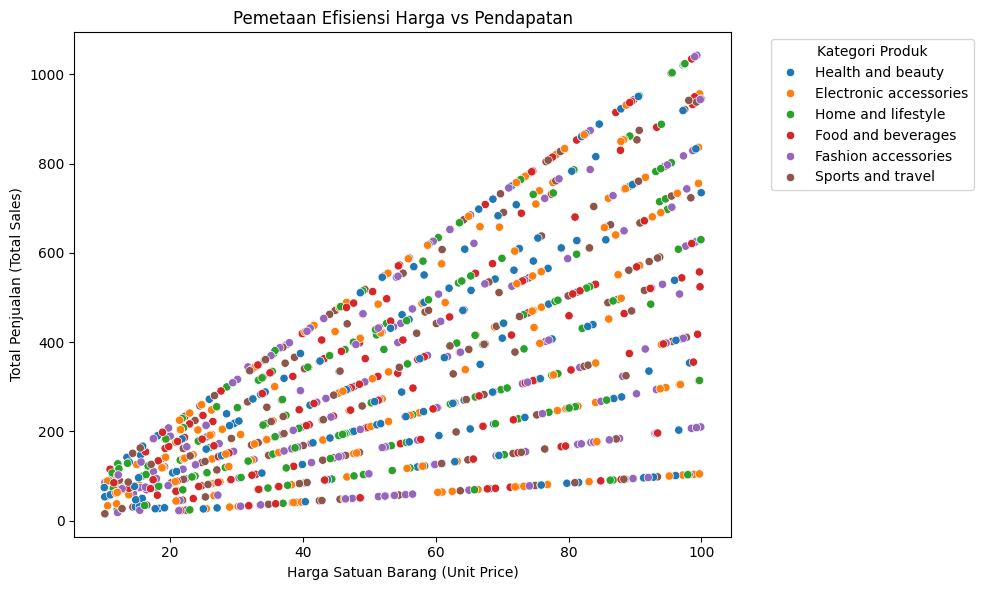

In [34]:


plt.figure(figsize=(10, 6))

# KOLOM 1 = Unit price, KOLOM 2 = Total Sales, KET.KOTAK KECIL = Product line
sns.scatterplot(x='Unit price', y='Total Sales', hue='Product line', data=df)

plt.title('Pemetaan Efisiensi Harga vs Pendapatan')
plt.xlabel('Harga Satuan Barang (Unit Price)')
plt.ylabel('Total Penjualan (Total Sales)')
plt.legend(title='Kategori Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Berdasarkan grafik Scatter Plot pemetaan efisiensi harga vs pendapatan

**Insight yang didapat:**
* Titik-titik di area kanan atas ini (terutama kategori Home and lifestyle dan Health and beauty) menunjukkan produk dengan harga satuan tinggi yang menghasilkan pendapatan besar.
* Titik-titik yang berada di area bawah meskipun harga satuannya tinggi Ini berarti produk mahal tersebut hanya terjual dalam jumlah sedikit (Quantity 1-2), sehingga modal besar yang tertanam belum kembali secara maksimal.

**action:**
* Evaluasi kategori produk yang menumpuk di area kiri bawah.
* Prioritaskan ketersediaan barang yang berada di garis diagonal paling atas

# **Heatmap**

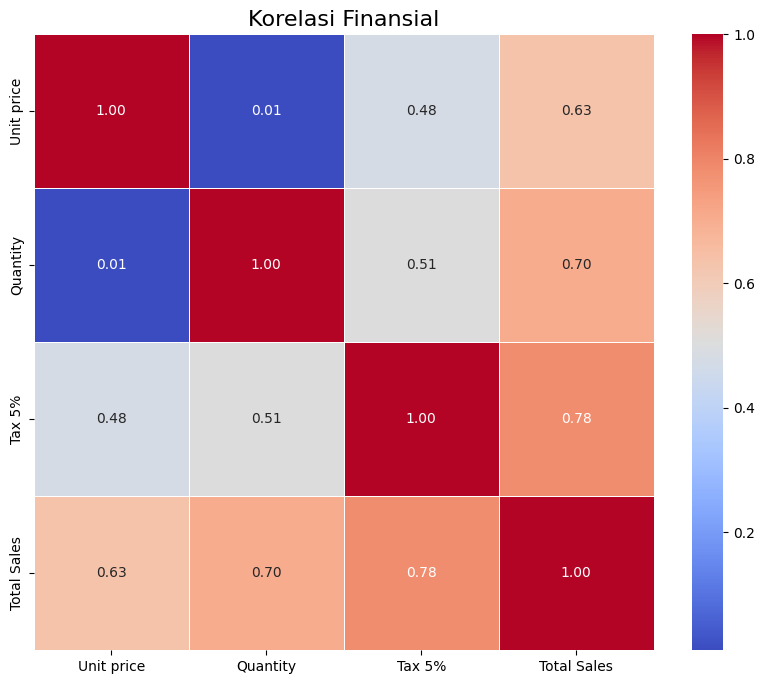

In [37]:
plt.figure(figsize=(10, 8))
corr_matrix = df[['Unit price', 'Quantity', 'Tax 5%', 'Total Sales']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Korelasi Finansial', fontsize=16)
plt.show()


Berdasarkan grafik Heatmap diatas,

**Insight yang didapat:**
* Korelasi antara Quantity dan Total Sales (0.70) ternyata lebih kuat dibandingkan korelasi antara Unit price dan Total Sales (0.63). Ini membuktikan bahwa saat ini pendapatan lebih banyak didorong oleh Volume Barang yang Terjual daripada harga barang itu sendiri.
* Korelasi antara Tax 5% dan Total Sales mencapai (0.78). Ini adalah angka korelasi tertinggi di luar angka 1.0. Artinya, setiap kali mengejar omzet besar, beban pajak akan naik sangat tajam dan langsung memotong margin keuntungan.
* Korelasi antara Unit price dan Quantity hampir nol (0.01). Ini sangat baik karena, menaikkan harga barang tidak membuat jumlah pelanggan yang membeli berkurang secara drastis.

**action:**
* Mengingat pajak memiliki korelasi yang sangat tinggi (0.78), perlu dipastikan menghitung Profit Bersih setelah pajak. Jangan terjebak pada angka Total Sales yang besar, karena beban pajaknya pun akan ikut membengkak.